In [2]:
# Import the libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import ascii
from astropy.coordinates import SkyCoord, Angle
import plotly.express as px
import scipy.stats as stats
from scipy.optimize import curve_fit

In [3]:
# LaTeX initialisation
# Many LaTeX parameters set to NULL otherwise plots take 84392409432 years to initialise and run

plt.savefig("amr_plot.png", dpi=300, bbox_inches="tight")
plt.rcParams['figure.dpi'] = 150
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

<Figure size 640x480 with 0 Axes>

In [4]:
# Read in data files
harris_p1 = pd.read_csv('HarrisPartI.csv')
harris_p3 = pd.read_csv('HarrisPartIII.csv')
krause = pd.read_csv('Krause21.csv')
vandenberg = pd.read_csv('vandenBerg_table2.csv') 

In [5]:
# Harris Part 1: make naming consistent
harris_p1.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p1['Object'] = harris_p1['Object'].astype(str) # make sure object column is string type
harris_p1['Object'] = harris_p1['Object'].str.replace(' ', '', regex=True) # remove spaces from object names

# Harris Part 3: make naming consistent
harris_p3.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p3['Object'] = harris_p3['Object'].astype(str) # make sure object column is string type
harris_p3['Object'] = harris_p3['Object'].str.replace(' ', '', regex=True) # remove spaces from object names

# Krause: naming already consistent
krause.loc[krause['Object'].str.upper() == 'RUPRECHT106', 'Object'] = 'Rup106' # change Ruprecht106 to Rup106 for consistency
krause.loc[krause['Object'].str.upper() == 'PALOMAR12', 'Object'] = 'Pal12' # change Palomar12 to Pal12 for consistency

# VandenBerg: make naming consistent
vandenberg.rename(columns={'#NGC': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
vandenberg['Object'] = vandenberg['Object'].astype(str) # make sure object column is string type
vandenberg['Object'] = 'NGC' + vandenberg['Object'] # add NGC to the start of each object
vandenberg.loc[vandenberg['Object'].str.upper() == 'NGCXXXX', 'Object'] = vandenberg.loc[vandenberg['Object'].str.upper() == 'NGCXXXX', 'Name'].astype(str) # change NGCXXXX to the Name column for those objects
vandenberg.loc[vandenberg['Object'].str.upper() == 'TER8', 'Object'] = 'Terzan8' # change Ter8 to Terzan8 for consistency


In [14]:
# number of globular clusters in each data set
print('Harris 1:', len(harris_p1))
print('Harris 3:', len(harris_p3))
print('Krause:', len(krause))
print('VandenBerg:', len(vandenberg))

# globular cluster overlaps between data sets
print('Harris 1 and Harris 3:', len(set(harris_p1['Object']) & set(harris_p3['Object'])))
print('Harris 1 and Krause:', len(set(harris_p1['Object']) & set(krause['Object'])))
print('Harris 1 and VandenBerg:', len(set(harris_p1['Object']) & set(vandenberg['Object'])))
print('Krause and VandenBerg:', len(set(krause['Object']) & set(vandenberg['Object'])))
print('All three:', len(set(harris_p1['Object']) & set(krause['Object']) & set(vandenberg['Object'])))

Harris 1: 157
Harris 3: 157
Krause: 61
VandenBerg: 55
Harris 1 and Harris 3: 157
Harris 1 and Krause: 61
Harris 1 and VandenBerg: 54
Krause and VandenBerg: 52
All three: 52


In [7]:
# merge data frames
merged_all = pd.merge(harris_p1, harris_p3, on='Object')
merged_all = pd.merge(merged_all, vandenberg, on='Object')
merged_all = pd.merge(merged_all, krause, on='Object')

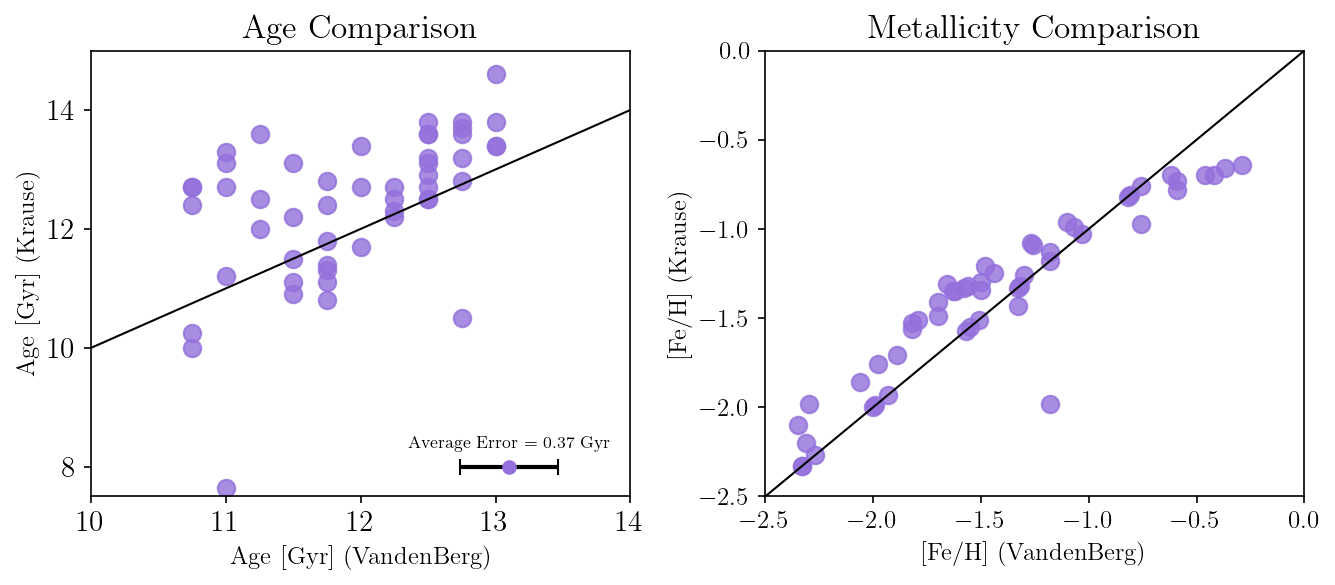

In [8]:
# Plotting comparisons between VandenBerg and Krause data
fig, axes = plt.subplots(1, 2, figsize=(9, 4))  # 1 row, 2 columns

# Age comparison
axes[0].scatter(merged_all['Age_x'], merged_all['Age_y'], color='mediumpurple', s=70, alpha=0.8)
axes[0].plot([10, 15], [10, 15], c='black', linestyle='-', lw=1, label='1:1 Line') # Add 1:1 line

# add a representative error bar in corner
errorbar = merged_all['Age_err'].mean()  # average error
axes[0].errorbar(13.1, 8, xerr=errorbar, marker='o', color='mediumpurple', ecolor='k', capsize=4, lw=2)
axes[0].text(13.1, 8.3, f'Average Error = {errorbar:.2f} Gyr', fontsize=8, ha='center') # error bar text

axes[0].set_xlabel('Age [Gyr] (VandenBerg)', fontsize=12)
axes[0].set_ylabel('Age [Gyr] (Krause)', fontsize=12)
axes[0].set_xlim(10, 14)
axes[0].set_ylim(7.5, 15)
axes[0].set_title('Age Comparison', fontsize=16)
axes[0].tick_params(axis='both', which='major', labelsize=14)

# [Fe/H] comparison
axes[1].scatter(merged_all['FeH_x'], merged_all['FeH_y'], color='mediumpurple', s=70, alpha=0.8)
axes[1].plot([-2.5, 0], [-2.5, 0], c='k', linestyle='-', lw=1, label='1:1 Line') # Add 1:1 line
axes[1].set_xlabel('[Fe/H] (VandenBerg)', fontsize=12)
axes[1].set_ylabel('[Fe/H] (Krause)', fontsize=12)
axes[1].set_xlim(-2.5, 0)
axes[1].set_ylim(-2.5, 0)
axes[1].set_title('Metallicity Comparison', fontsize=16)
axes[1].tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()

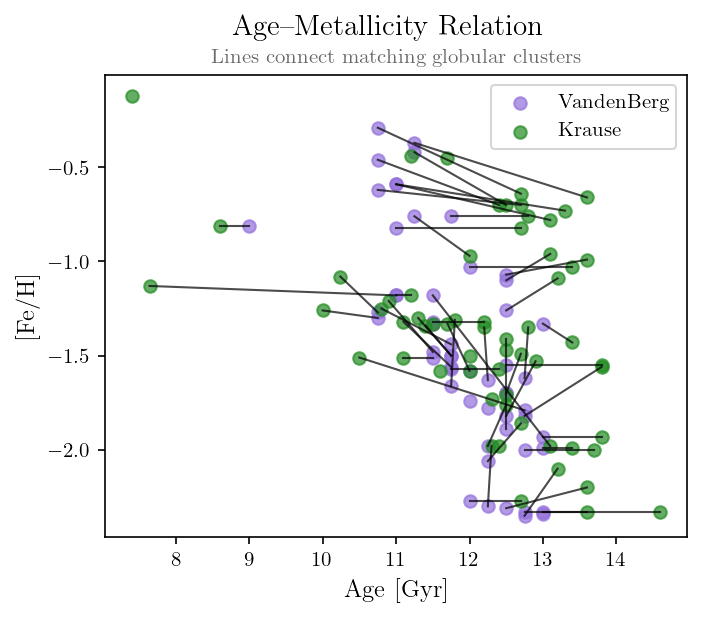

In [15]:
# Age-metallicity plot with data from VandenBerg and Krause with lines connecting matching objects
plt.figure(figsize=(5, 4))
plt.scatter(vandenberg['Age'], vandenberg['FeH'], marker='o', c='mediumpurple', label='VandenBerg', alpha=0.7)
plt.scatter(krause['Age'], krause['FeH'], marker='o', c='forestgreen', label='Krause', alpha=0.7)

# Connect matching objects
for object in set(vandenberg['Object']).intersection(krause['Object']): # find common objects
    v = vandenberg[vandenberg['Object'] == object].iloc[0] # get object row for vandenberg
    k = krause[krause['Object'] == object].iloc[0]  # get object row for krause
    plt.plot([v['Age'], k['Age']], [v['FeH'], k['FeH']],color='k', linestyle='-', linewidth=1, alpha=0.7) # plot line between same objects

# labels
plt.suptitle('Age–Metallicity Relation', fontsize=14)
plt.title('Lines connect matching globular clusters', fontsize=10, color='dimgray')
plt.xlabel('Age [Gyr]', fontsize=12)
plt.ylabel('[Fe/H]', fontsize=12)
plt.legend()
plt.show()

In [10]:
# keep only the vandenberg (x) values for FeH, Age, and R_gc
merged_all['FeH'] = merged_all['FeH_x']
merged_all['Age'] = merged_all['Age_x']
merged_all['r_gc'] = merged_all['R_gc'] # The Galactocentric radius from Harris and VandenBerg have the same values

# drop the unusable columns
merged_all = merged_all.drop(columns=['FeH_x', 'FeH_y', 'Age_x', 'Age_y', 'R_gc', 'R_G'])

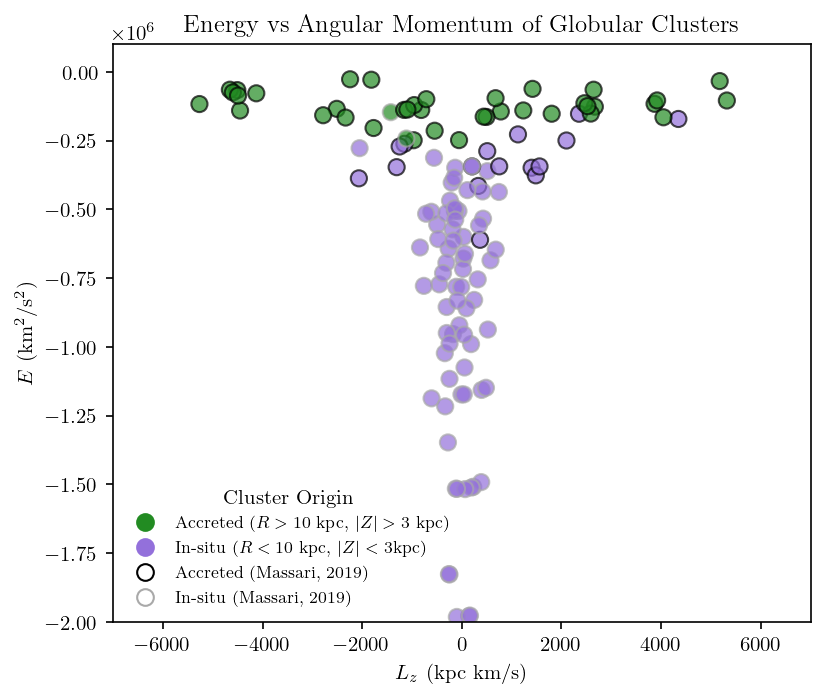

In [ ]:
progenitor = pd.read_csv('Progenitor.csv') # Cluster origins based on Massari et al. (2019)

# Energy vs Angular Momentum
merged_harris = pd.merge(harris_p1, harris_p3, on='Object')
merged_harris = pd.merge(merged_harris, progenitor, on='Object')

# Constants (assuming certain values for the Galaxy)
G = 4.30091e-6  # Gravitational constant in kpc (km/s)^2 / Msun
M_gal = 6e11    # Mass of the Milky Way in solar masses within 100 kpc (Deason et al. 2021)

# Calculate energy (approximate)
merged_harris['E'] = -G * M_gal / merged_harris['R_gc'] + 0.5 * merged_harris['v_r']**2
# Calculate z-component of angular momentum (approximate)
merged_harris['Lz'] = merged_harris['R_gc'] * merged_harris['v_r'] # very simplified (no mass or tangential velocity T_T)

# Identify accreted clusters
mask = (harris_p1["R_gc"] > 10) & (abs(harris_p1["Z"]) > 3)
accreted_names = harris_p1.loc[mask, "Object"]

# face colour from previously defined accretion
merged_harris['facecolor'] = np.where(merged_harris['Object'].isin(accreted_names),'forestgreen','mediumpurple')

# Edge colors based on conclusions from papers
edge_colors = merged_harris['Progenitor'].map({'IS': 'darkgray', 'AC': 'k'})

# Plot E vs Lz
plt.figure(figsize=(6, 5))
plt.scatter(merged_harris['Lz'], merged_harris['E'], c=merged_harris['facecolor'], s=60, alpha=0.7, ec=edge_colors, lw=1)
plt.xlabel(r'$L_z$ (kpc km/s)')
plt.ylabel(r'$E$ (km$^2$/s$^2$)')
plt.title('Energy vs Angular Momentum of Globular Clusters')
plt.ylim(-2e6, 0.1e6)
plt.xlim(-7000, 7000)
legend_handles = [
    plt.Line2D([], [], marker='o', color='forestgreen', markersize=8, linestyle='None', label=r'Accreted ($R > 10$ kpc, $|Z| > 3$ kpc)'),
    plt.Line2D([], [], marker='o', color='mediumpurple', markersize=8, linestyle='None', label=r'In-situ ($R < 10$ kpc, $|Z| < 3$kpc)'),
    plt.Line2D([], [], marker='o', color='w', markeredgecolor='k', markersize=8, linestyle='None', label='Accreted (Massari, 2019)'),
    plt.Line2D([], [], marker='o', color='w', markeredgecolor='darkgray', markersize=8, linestyle='None', label='In-situ (Massari, 2019)')
]
plt.legend(handles=legend_handles, loc='best', frameon=False, title='Cluster Origin', fontsize=8)
plt.show()

# For visualisation purposes, some outlier clusters have not been plotted but they follow the same trend